**Lab 4-Tasks**  
**Course: ANN** 

**Khair ul wara Hussain**
**Student Id: FA23-BAI-022**

### Lab Task 1: Data and Weight Setup

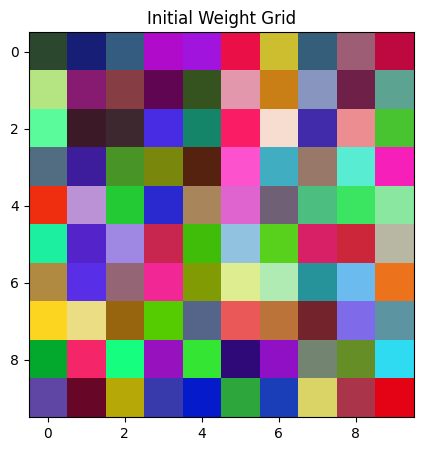

Data shape: (200, 3)
Data min: 0.005061583846218687
Data max: 0.9997176732861306
Weights shape: (10, 10, 3)
Weights min: 0.004632023004602859
Weights max: 0.9968742518459474


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

data = np.random.rand(200, 3)
weights = np.random.rand(10, 10, 3)

plt.figure(figsize=(5,5))
plt.imshow(weights)
plt.title('Initial Weight Grid')
plt.show()

print("Data shape:", data.shape)
print("Data min:", data.min())
print("Data max:", data.max())
print("Weights shape:", weights.shape)
print("Weights min:", weights.min())
print("Weights max:", weights.max())

### Lab Task 2: Distance Calculation

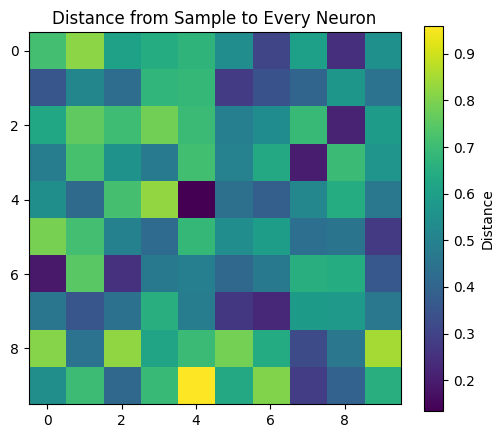

Distance array shape: (10, 10)
Smallest distance: 0.13437863807304615
Row: 4 Column: 4


In [2]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2, axis=-1))

sample = data[np.random.randint(len(data))]
distances = euclidean_distance(weights, sample)

plt.figure(figsize=(6,5))
plt.imshow(distances, cmap='viridis')
plt.colorbar(label='Distance')
plt.title('Distance from Sample to Every Neuron')
plt.show()

row, col = np.unravel_index(np.argmin(distances), distances.shape)
print("Distance array shape:", distances.shape)
print("Smallest distance:", distances.min())
print("Row:", row, "Column:", col)

### Lab Task 3: Finding the Winner (BMU)

In [3]:
def find_bmu(weights, x):
    distances = euclidean_distance(weights, x)
    row, col = np.unravel_index(np.argmin(distances), distances.shape)
    return int(row), int(col)

sample_ids = np.random.choice(len(data), 5, replace=False)

print(f"{'Sample':<10}{'BMU':<12}{'Distance'}")
for i in sample_ids:
    bmu = find_bmu(weights, data[i])
    dist = euclidean_distance(weights[bmu], data[i])
    print(f"{i:<10}{str(bmu):<12}{dist:.4f}")

Sample    BMU         Distance
95        (2, 4)      0.1514
112       (9, 7)      0.1481
37        (8, 9)      0.1552
151       (8, 1)      0.1024
191       (5, 5)      0.1342


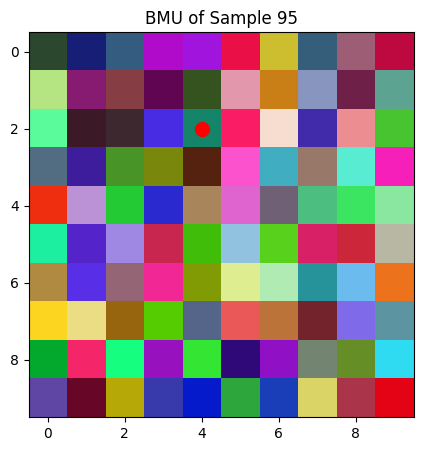

In [4]:
bmu = find_bmu(weights, data[sample_ids[0]])

plt.figure(figsize=(5,5))
plt.imshow(weights)
plt.scatter(bmu[1], bmu[0], c='red', marker='o', s=100)
plt.title('BMU of Sample ' + str(sample_ids[0]))
plt.show()

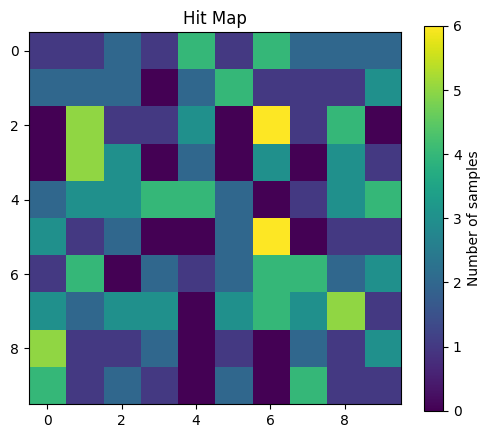

Total samples counted: 200
Neurons with at least one hit: 82


In [5]:
hits = np.zeros((10, 10), dtype=int)
for x in data:
    r, c = find_bmu(weights, x)
    hits[r, c] += 1

plt.figure(figsize=(6,5))
plt.imshow(hits, cmap='viridis')
plt.colorbar(label='Number of samples')
plt.title('Hit Map')
plt.show()

print("Total samples counted:", hits.sum())
print("Neurons with at least one hit:", np.count_nonzero(hits))

### Lab Task 4: Neighborhood Function

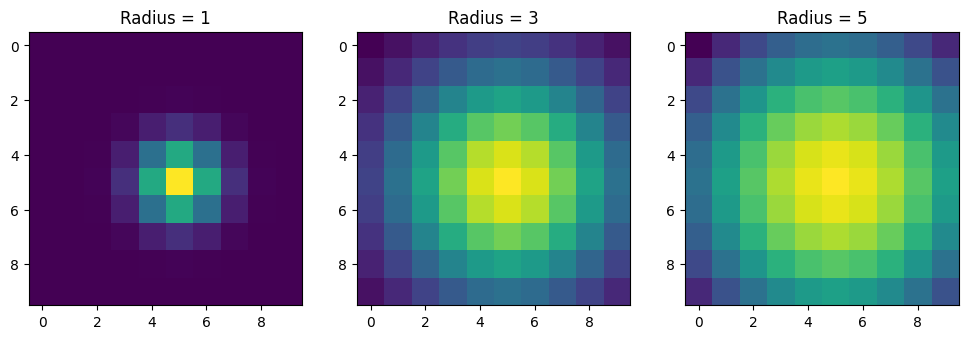

In [6]:
def neighborhood(grid_size, bmu, radius):
    rows, cols = np.indices((grid_size, grid_size))
    dist_sq = (rows - bmu[0]) ** 2 + (cols - bmu[1]) ** 2
    return np.exp(-dist_sq / (2 * radius ** 2))

plt.figure(figsize=(12,4))
for i, r in enumerate([1, 3, 5]):
    plt.subplot(1, 3, i + 1)
    plt.imshow(neighborhood(10, (5, 5), r), cmap='viridis')
    plt.title('Radius = ' + str(r))
plt.show()

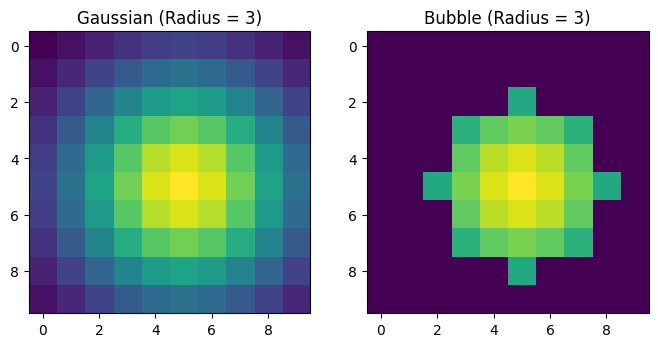

In [7]:
def neighborhood_bubble(grid_size, bmu, radius):
    rows, cols = np.indices((grid_size, grid_size))
    dist = np.sqrt((rows - bmu[0]) ** 2 + (cols - bmu[1]) ** 2)
    h = neighborhood(grid_size, bmu, radius)
    h[dist > radius] = 0
    return h

plt.figure(figsize=(8,4))
plt.subplot(1, 2, 1)
plt.imshow(neighborhood(10, (5, 5), 3), cmap='viridis')
plt.title('Gaussian (Radius = 3)')
plt.subplot(1, 2, 2)
plt.imshow(neighborhood_bubble(10, (5, 5), 3), cmap='viridis')
plt.title('Bubble (Radius = 3)')
plt.show()

In [8]:
h = neighborhood(10, (5, 5), 2)
print("h at BMU:", h[5, 5])
print("h at 3 steps away:", h[5, 8])

h at BMU: 1.0
h at 3 steps away: 0.32465246735834974


### Lab Task 5: One Weight Update Step

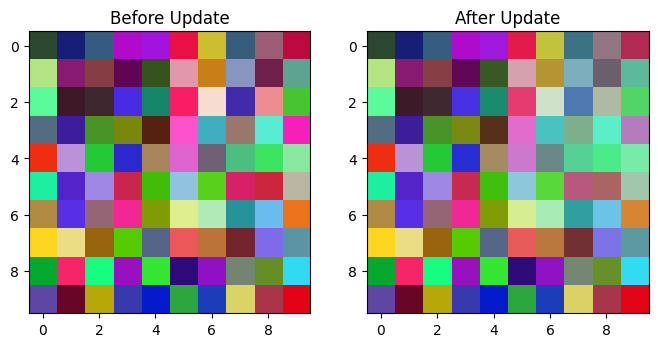

In [9]:
def update_weights(weights, x, bmu, learning_rate, radius):
    h = neighborhood(weights.shape[0], bmu, radius)
    return weights + learning_rate * h[:, :, np.newaxis] * (x - weights)

x = data[0]
bmu = find_bmu(weights, x)
new_weights = update_weights(weights, x, bmu, 0.5, 2)

plt.figure(figsize=(8,4))
plt.subplot(1, 2, 1)
plt.imshow(weights)
plt.title('Before Update')
plt.subplot(1, 2, 2)
plt.imshow(new_weights)
plt.title('After Update')
plt.show()

In [10]:
change = np.sum(np.abs(new_weights - weights))
print("Total absolute change in weights:", change)

before = euclidean_distance(weights[bmu], x)
after = euclidean_distance(new_weights[bmu], x)
print("Distance before update:", before)
print("Distance after update:", after)

if after < before:
    print("The distance decreased")
else:
    print("The distance did not decrease")

Total absolute change in weights: 8.68310343621436
Distance before update: 0.10409052615689075
Distance after update: 0.05204526307844544
The distance decreased


### Lab Task 6: Training Loop

In [11]:
lr_history = []
radius_history = []

def train_som(data, grid_size, iterations, lr_start, radius_start, weights=None):
    if weights is None:
        weights = np.random.rand(grid_size, grid_size, 3)
    weights = weights.copy()

    for t in range(iterations):
        lr = lr_start * np.exp(-t / iterations)
        radius = radius_start * np.exp(-t * np.log(radius_start) / iterations)
        x = data[np.random.randint(len(data))]
        bmu = find_bmu(weights, x)
        weights = update_weights(weights, x, bmu, lr, radius)

        if t % 100 == 0:
            lr_history.append(lr)
            radius_history.append(radius)

    return weights

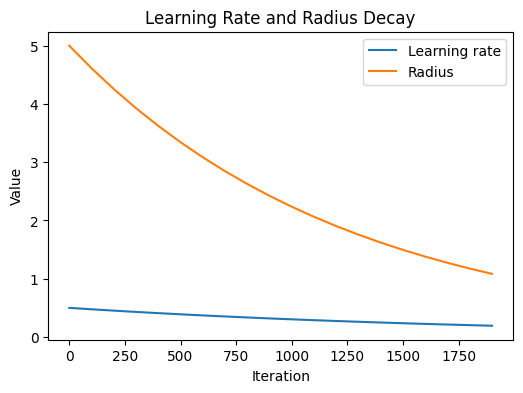

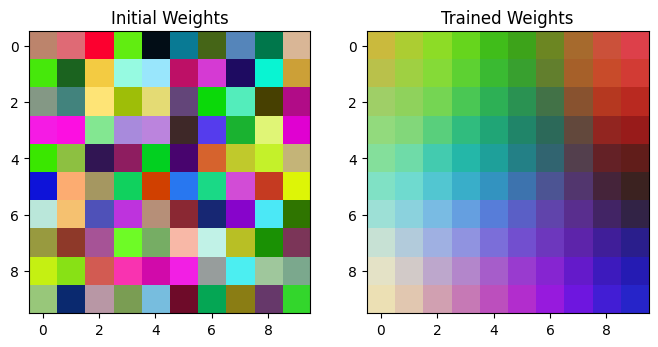

In [12]:
initial_weights = np.random.rand(10, 10, 3)
trained_weights = train_som(data, 10, 2000, 0.5, 5, weights=initial_weights)

steps = range(0, 2000, 100)
plt.figure(figsize=(6,4))
plt.plot(steps, lr_history, label='Learning rate')
plt.plot(steps, radius_history, label='Radius')
plt.xlabel('Iteration')
plt.ylabel('Value')
plt.title('Learning Rate and Radius Decay')
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.subplot(1, 2, 1)
plt.imshow(initial_weights)
plt.title('Initial Weights')
plt.subplot(1, 2, 2)
plt.imshow(trained_weights)
plt.title('Trained Weights')
plt.savefig('task6_result.png')
plt.show()

### Lab Task 7: Measuring Training Quality

In [13]:
def quantization_error(data, weights):
    distances = euclidean_distance(data[:, np.newaxis, np.newaxis, :], weights[np.newaxis])
    return distances.reshape(len(data), -1).min(axis=1).mean()

def train_som(data, grid_size, iterations, lr_start, radius_start, weights=None):
    if weights is None:
        weights = np.random.rand(grid_size, grid_size, 3)
    weights = weights.copy()
    errors = []

    for t in range(iterations):
        lr = lr_start * np.exp(-t / iterations)
        radius = radius_start * np.exp(-t * np.log(radius_start) / iterations)
        x = data[np.random.randint(len(data))]
        bmu = find_bmu(weights, x)
        weights = update_weights(weights, x, bmu, lr, radius)

        if t % 100 == 0:
            lr_history.append(lr)
            radius_history.append(radius)
        if t % 250 == 0:
            errors.append(quantization_error(data, weights))

    return weights, errors

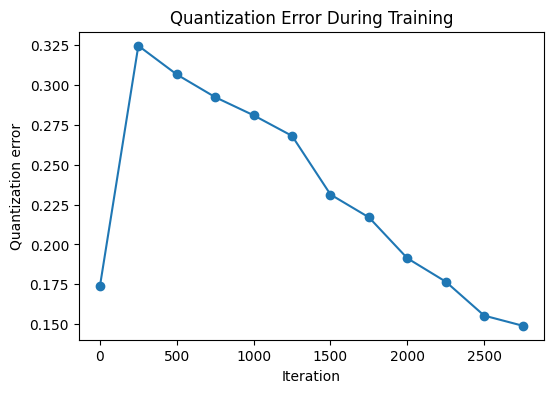

First error: 0.1737557988287866
Last error: 0.14901228946358233
Reduction: 14.24%


In [14]:
trained_weights, errors = train_som(data, 10, 3000, 0.5, 5)

plt.figure(figsize=(6,4))
plt.plot(range(0, 3000, 250), errors, marker='o')
plt.xlabel('Iteration')
plt.ylabel('Quantization error')
plt.title('Quantization Error During Training')
plt.show()

print("First error:", errors[0])
print("Last error:", errors[-1])
print("Reduction: {:.2f}%".format((errors[0] - errors[-1]) / errors[0] * 100))

### Lab Task 8: Parameter Experiments

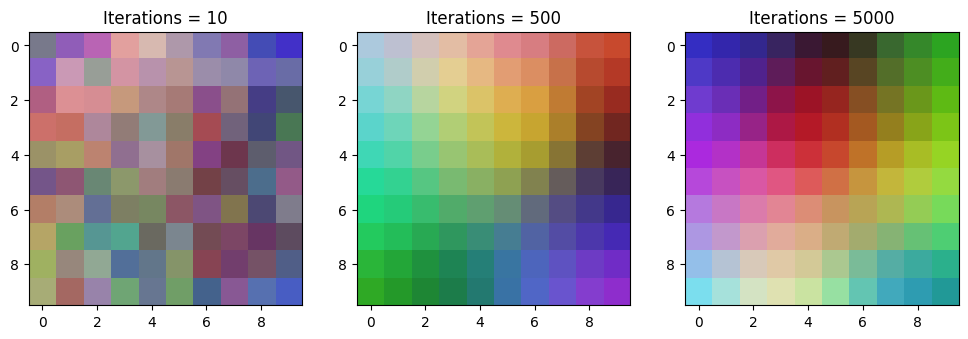

In [15]:
experiments = []

plt.figure(figsize=(12,4))
for i, n in enumerate([10, 500, 5000]):
    w, _ = train_som(data, 10, n, 0.5, 5)
    plt.subplot(1, 3, i + 1)
    plt.imshow(w)
    plt.title('Iterations = ' + str(n))
    experiments.append(('Iterations', n, quantization_error(data, w)))
plt.show()

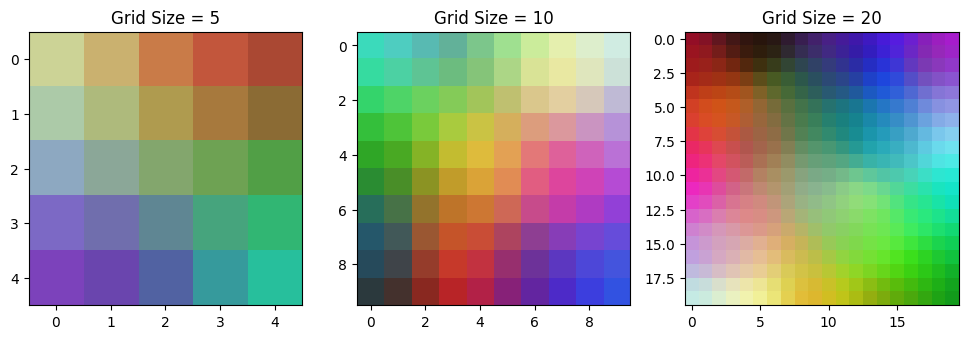

In [16]:
plt.figure(figsize=(12,4))
for i, g in enumerate([5, 10, 20]):
    w, _ = train_som(data, g, 2000, 0.5, g / 2)
    plt.subplot(1, 3, i + 1)
    plt.imshow(w)
    plt.title('Grid Size = ' + str(g))
    experiments.append(('Grid size', g, quantization_error(data, w)))
plt.show()

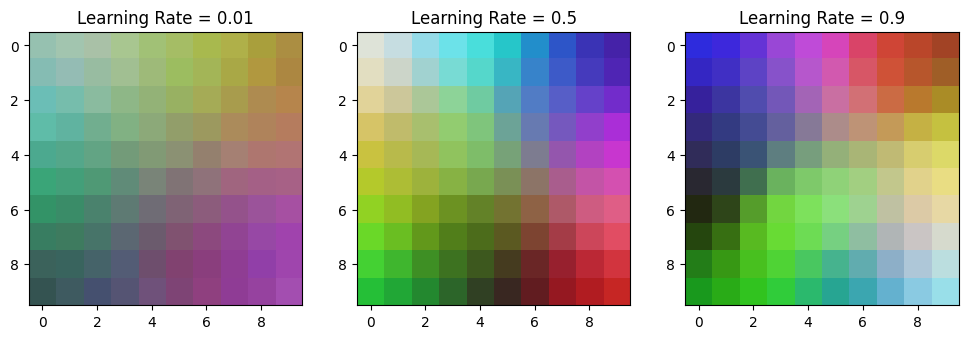

In [17]:
plt.figure(figsize=(12,4))
for i, lr in enumerate([0.01, 0.5, 0.9]):
    w, _ = train_som(data, 10, 2000, lr, 5)
    plt.subplot(1, 3, i + 1)
    plt.imshow(w)
    plt.title('Learning Rate = ' + str(lr))
    experiments.append(('Learning rate', lr, quantization_error(data, w)))
plt.show()

In [18]:
print(f"{'Setting':<18}{'Value':<10}{'Final Error'}")
for name, value, err in experiments:
    print(f"{name:<18}{value:<10}{err:.4f}")

Setting           Value     Final Error
Iterations        10        0.2448
Iterations        500       0.1571
Iterations        5000      0.1316
Grid size         5         0.2475
Grid size         10        0.1371
Grid size         20        0.0792
Learning rate     0.01      0.2634
Learning rate     0.5       0.1450
Learning rate     0.9       0.1408


### Lab Task 9: Mini Project with Your Own Data

In [19]:
base_colors = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
labels = np.random.randint(0, 3, 100)
samples = np.clip(base_colors[labels] + np.random.normal(0, 0.1, (100, 3)), 0, 1)

print("Samples shape:", samples.shape)
print("Min value:", samples.min())
print("Max value:", samples.max())

Samples shape: (100, 3)
Min value: 0.0
Max value: 1.0


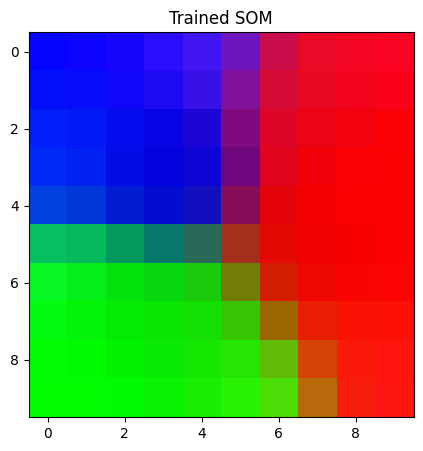

In [20]:
som_weights, _ = train_som(samples, 10, 3000, 0.5, 5)

plt.figure(figsize=(5,5))
plt.imshow(som_weights)
plt.title('Trained SOM')
plt.show()

Neurons that received at least one sample: 49


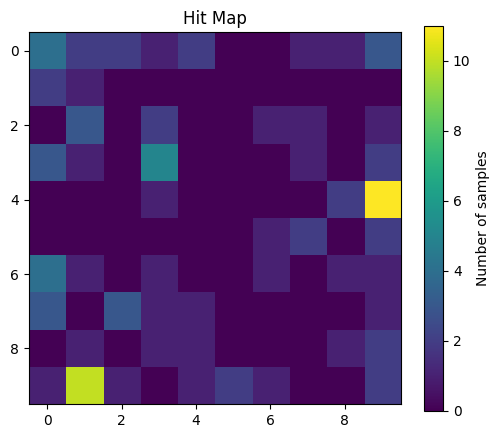

In [21]:
groups = {}
for i, x in enumerate(samples):
    bmu = find_bmu(som_weights, x)
    groups.setdefault(bmu, []).append(i)

print("Neurons that received at least one sample:", len(groups))

hits = np.zeros((10, 10), dtype=int)
for pos, ids in groups.items():
    hits[pos] = len(ids)

plt.figure(figsize=(6,5))
plt.imshow(hits, cmap='viridis')
plt.colorbar(label='Number of samples')
plt.title('Hit Map')
plt.show()